# 03 · The oracle, part 2 — preference & reliability

**Execution status:** 🟢 EXECUTED (CPU, outputs saved)
**Plan reference:** PLAN §III.5 (BT) · §III.7 (power) · §III.8 (judge) · THEORY §T4–T6 · PREREG §5–§6

The second independent signal: a **pairwise preference** protocol adjudicated by a VLM judge, then earned trust. A preference delta only counts if the judge tracks human judgment (**reliability gate**, chance-corrected) *and* the comparison had enough pairs to see the effect (**power gate**). We show the verbatim judge template, the both-orders→tie logic on a mock judge, the κ-paradox that forces a two-coefficient agreement gate, the executed power sizing, and the style-controlled Bradley–Terry endpoint itself.

| | |
|---|---|
| **Inputs** | `p19.judge`, `p19.agreement`, `p19.power`, `p19.bt_model`, synthetic labels |
| **Outputs** | reliability gate + F11, decisive-pair table, mis-plug guard, BT utilities |
| **Runtime** | ~15 s |

*Project 19 — Anatomy of a Design Skill. Governance: `CLAUDE.md`. Plan: `PLAN.md`. Derivations:
`THEORY.md`. Freeze: `PREREGISTRATION.md`. This notebook imports tested machinery from the `p19`
package and carries the narrative; it never re-implements logic that lives in `src/p19/`.*

In [1]:
%matplotlib inline
# Bootstrap: locate the repo root (repo-relative — no hardcoded paths) and make p19 importable.
import sys, pathlib
_here = pathlib.Path.cwd()
_root = next((c for c in [_here, *_here.parents]
              if (c / "pyproject.toml").exists() and (c / "src" / "p19").exists()), _here)
if str(_root / "src") not in sys.path:
    sys.path.insert(0, str(_root / "src"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from p19 import REPO_ROOT
np.random.seed(0)                      # notebook-level seed; every generator also takes an explicit seed
pd.set_option("display.max_columns", 40); pd.set_option("display.width", 120)
print("p19 ready · repo:", REPO_ROOT.name)

p19 ready · repo: steering-llm-aesthetics


## §III.8 · The judge, and its template (verbatim)

The primary judge is **Gemini 2.5 Flash** (cheap, different model family from Qwen → avoids
self-enhancement bias), with a **GPT-4o audit** on 15 %. It sees the brief and two screenshots and
returns strict JSON. The template is frozen in `p19.judge` and reproduced live below — note it
explicitly tells the judge *not* to reward length or colorfulness per se (the exact biases the
style-controlled BT will also subtract).

In [2]:
# The verbatim judge system + user template (p19.judge; PLAN Appendix C).
from p19 import judge
print("=== SYSTEM ===\n" + judge.JUDGE_SYSTEM)
print("\n=== USER (template) ===\n" + judge.JUDGE_USER_TEMPLATE[:520] + " ...")
print("\ncriteria:", judge.CRITERIA)

=== SYSTEM ===
You are a senior product designer evaluating two rendered web user interfaces, A and B, that were built for the SAME brief. Judge which is the better-designed interface FOR THAT BRIEF. Base your judgment on deliberate, brief-appropriate design choices — not on which page is merely longer, more colorful, or more filled-in. A page is not better for having more elements or brighter colors; it is better for coherent color, clear layout and hierarchy, considered typography, quality component patterns, restraint (absence of generic "AI-slop" tells such as purple gradients, Inter/Roboto, centered hero-with-a-big-number, three identical icon cards, uniform rounded corners, excessive animation), and fit to the brief. Return ONLY valid JSON in the specified schema. Do not add prose outside the JSON.

=== USER (template) ===
BRIEF: "{brief_text}"

You are shown two screenshots: image A (first) and image B (second), both rendered at 1440x900. Evaluate each on: color/palette coherenc

## §III.8 · Both orders, or it's a tie — the position-bias control

VLM judges have a position bias (they favor whichever page is shown first). So every pair is judged in
**both orders**; a winner counts **only if it is consistent across orders**, otherwise the verdict is
a **tie**. `MockJudge` is a deterministic, network-free stand-in that lets us exercise exactly this
logic on the CPU. Below, a clear pair resolves to a winner; a near-equal pair under position bias
resolves — correctly — to a tie.

In [3]:
# MockJudge dry-run: both-orders adjudication → tie on order-inconsistency (p19.judge; PLAN §III.8).
from p19.judge import MockJudge, PairInput
mj = MockJudge(quality={"FULL":1.0,"NEUTRAL":0.0,"AOI-C1":0.15,"AOI-C2":0.12},
               position_bias=0.30, tie_margin=0.15)  # bias > tie_margin exposes the tie logic
demo = []
for a, b in [("FULL","NEUTRAL"), ("AOI-C1","AOI-C2")]:
    j = mj.judge_pair(PairInput("water-tracker landing", a, b, a, b, "L01"))
    demo.append({"pair": f"{a} vs {b}", "order (A,B)→": j.raw_ab_winner, "order (B,A)→": j.raw_ba_winner,
                 "consistent": j.consistent, "final winner": j.winner})
pd.DataFrame(demo).set_index("pair")

,"order (A,B)→","order (B,A)→",consistent,final winner
pair,,,,
FULL vs NEUTRAL,A,B,True,A
AOI-C1 vs AOI-C2,A,A,False,tie


**FULL vs NEUTRAL** wins consistently in both orders → a real winner. **AOI-C1 vs AOI-C2** (nearly
equal) flips with the presentation order → the judge is guessing → **tie**. Those ties are not thrown
away; they feed the Davidson tie term in Bradley–Terry, which reads an order-inconsistent verdict as
evidence of *near-equality*.

## §III.8 / THEORY §T4 · Trusting the judge — the κ-paradox and a two-coefficient gate

Raw agreement is not enough: when one outcome dominates (the skill usually wins), *chance* agreement
is nearly as high as observed agreement, and **Krippendorff's α collapses even though the judge is
excellent** — the **κ-paradox**. Gwet's **AC1** uses a skew-robust chance model that does not
collapse. So the gate is **disjunctive**: pass if `α_K ≥ 0.667` **OR** `AC1 ≥ 0.80 under demonstrable
skew`. We reproduce THEORY §T4.3's exact worked example below.

In [4]:
# THEORY T4.3 reproduced: identical 90% agreement, different marginal skew → α_K moves, AC1 does not.
from p19 import agreement, synthetic as syn
panels = syn.agreement_panels()
tab = []
for name, u in panels.items():
    tab.append({"panel": name,
                "α_K (ordinal)": round(agreement.krippendorff_alpha(u, "ordinal", categories=[0,1]), 3),
                "AC1 (Gwet)": round(agreement.gwet_ac1(u, categories=[0,1]), 3),
                "π_max (skew)": round(agreement.marginal_distribution(u, categories=[0,1])["pi_max"], 3)})
pd.DataFrame(tab).set_index("panel")

,α_K (ordinal),AC1 (Gwet),π_max (skew)
panel,,,
skewed,0.447,0.878,0.9
balanced,0.801,0.800,0.5


Same 90 % agreement in both panels. Skewed: **α_K = 0.447** (looks like a bad judge) but **AC1 =
0.878** (it isn't). Balanced: the two coincide at **0.80**. This is *why* the gate needs AC1 — without
it, a good judge on a lopsided contrast would be wrongly rejected.

In [5]:
# The preregistered gate on (a) a realistic synthetic judge panel and (b) the skewed κ-paradox panel.
labels = syn.reliability_labels(n=100, seed=1)
gate = agreement.reliability_gate(labels, categories=[-2,-1,0,1,2])
gate_skew = agreement.reliability_gate(panels["skewed"], categories=[0,1])
print("realistic judge panel :", {k:(round(v,3) if isinstance(v,float) else v) for k,v in gate.items()})
print("κ-paradox skewed panel:", {k:(round(v,3) if isinstance(v,float) else v) for k,v in gate_skew.items()})
print("\n→ the skewed panel PASSES specifically via the '%s' rung (AC1 rescue under skew)" % gate_skew["rung"])

realistic judge panel : {'alpha_K': 0.79, 'AC1': 0.947, 'pi_max': 0.885, 'demonstrable_skew': True, 'pass': True, 'rung': 'alpha'}
κ-paradox skewed panel: {'alpha_K': 0.447, 'AC1': 0.878, 'pi_max': 0.9, 'demonstrable_skew': True, 'pass': True, 'rung': 'ac1_skew'}

→ the skewed panel PASSES specifically via the 'ac1_skew' rung (AC1 rescue under skew)


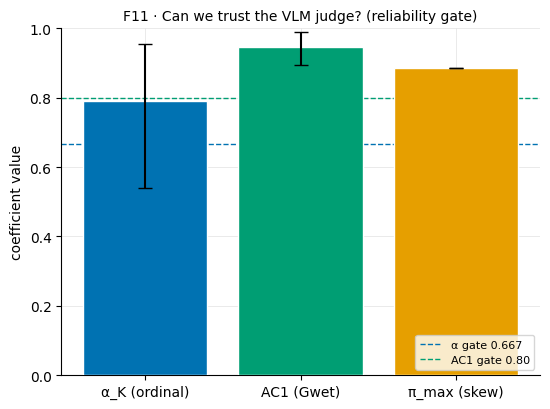

If the gate FAILS → cascade: revise rubric → swap judge (GPT-4o/Claude) → escalate humans to N=300 & down-weight judge → objective-only null decisions (PREREG §5).


In [6]:
# F11 — judge reliability with bootstrap CIs (p19.agreement.bootstrap_ci + p19.figures).
from p19 import figures
a_ci = agreement.bootstrap_ci(lambda u: agreement.krippendorff_alpha(u,"ordinal",[-2,-1,0,1,2]), labels, B=800)
ac_ci = agreement.bootstrap_ci(lambda u: agreement.gwet_ac1(u,[-2,-1,0,1,2]), labels, B=800)
figures.reliability_bars(gate["alpha_K"], gate["AC1"], gate["pi_max"],
                         alpha_ci=(a_ci["lo"], a_ci["hi"]), ac1_ci=(ac_ci["lo"], ac_ci["hi"])); plt.show()
print("If the gate FAILS → cascade: revise rubric → swap judge (GPT-4o/Claude) → escalate humans to "
      "N=300 & down-weight judge → objective-only null decisions (PREREG §5).")

## §III.7 / THEORY §T6 · The power gate — how many pairs to see an effect

Preference comparisons are paired (same prompt, two cells, seed-matched). McNemar sizing (THEORY §T6.2)
gives the number of **decisive** (order-consistent) pairs needed to detect a given preference split at
80 % power. These are the numbers a reviewer will spot-check.

In [7]:
# Decisive-pair sizing — reproduces PLAN's 200/80/780 headline (p19.power; THEORY T6.2).
from p19 import power
size = pd.DataFrame([{"split": lbl, "required decisive pairs": round(power.required_decisive_pairs(ws), 1)}
                     for ws, lbl in [(0.60,"60/40"), (0.65,"65/35"), (0.55,"55/45")]]).set_index("split")
print(size.to_string())
# The documented mis-plug guard: plugging a conditional split as the marginal gap gives a WRONG ~93.
print("\nmis-plug (conditional split 0.2 with p_d=0.5) →", round(power.misplug_value(), 2),
      "  (neither 200 nor 400 — the guard warns; use required_decisive_pairs)")
rec = power.reconcile_decisive(0.60, 0.5)
print("reconciliation: N_total %.1f × p_d = %.1f  ==  N_decisive %.1f  ✔"
      % (rec["n_total"], rec["n_total_x_pd"], rec["n_decisive_direct"]))

       required decisive pairs
split                         
60/40                    193.8
65/35                     84.8
55/45                    782.5

mis-plug (conditional split 0.2 with p_d=0.5) → 93.25   (neither 200 nor 400 — the guard warns; use required_decisive_pairs)
reconciliation: N_total 387.7 × p_d = 193.8  ==  N_decisive 193.8  ✔


In [8]:
# BT-utility power at the FROZEN allocation, simulated on synthetic effect sizes (PLAN §III.7, PREREG §6).
fa = power.frozen_allocation_power(tie_rate=0.15, n_sims=1500, seed=0)
pd.DataFrame([{"edge": r["edge"], "judged pairs": n, "assumed split": r["assumed_win_share"],
               "expected decisive": round(r["expected_decisive"]), "required decisive": round(r["required_decisive"]),
               "empirical power": round(r["power"], 2)}
              for r, (_, n, _) in zip(fa, power.FROZEN_ALLOCATION)]).set_index("edge")

,judged pairs,assumed split,expected decisive,required decisive,empirical power
edge,,,,,
FULL-NEUTRAL,200,0.60,170,194,0.70
FULL-LOO-Ci,120,0.60,102,194,0.48
AOI-Ci-NEUTRAL,80,0.65,68,85,0.67
FULL-BEAUTY1,120,0.60,102,194,0.48


**Reading the power table.** At the *conservative* assumed splits and a 15 % tie rate, the headline
FULL–NEUTRAL edge (200 pairs) lands near the 0.80 boundary and the smaller edges below it — the
allocation is sized for the assumed effects, and the **gate is exactly what flags an edge that falls
short**. Per the pre-stated contingency, an under-powered confirmatory edge gets its seed-pairs topped
up (up to the 4k budget) — it is never silently reinterpreted as a null. Small expected effects are
lightly powered on the *preference* channel **on purpose**: their non-null status can still be
established via the fully-powered **objective** channel (the two-signal OR).

## §III.5 · The preference endpoint — style-controlled Bradley–Terry

Finally the endpoint itself. Bradley–Terry gives each cell a latent quality **utility** (reference
NEUTRAL = 0); order-inconsistent ties feed a **Davidson** tie term ν; and per-page **style covariates**
(log DOM size, log tokens, colorfulness, …) are regressed out so the utility is *substance*, not the
judge's length/colorfulness bias (THEORY §T5.4). Below we fit it on synthetic confirmatory-edge
judgments with a planted quality order.

In [9]:
# Fit the Davidson BT model on synthetic judgments with a planted order (p19.bt_model; THEORY T5).
from p19 import bt_model
scores = {"NEUTRAL":0.0,"FULL":1.4,"LOO-C1":1.05,"LOO-C5":0.55,"AOI-C1":0.22,"AOI-C5":0.50,"BEAUTY1":0.60}
edges = [("FULL","NEUTRAL"),("FULL","LOO-C1"),("FULL","LOO-C5"),("AOI-C1","NEUTRAL"),
         ("AOI-C5","NEUTRAL"),("BEAUTY1","NEUTRAL"),("FULL","BEAUTY1")]
prompts = [f"P{i}" for i in range(40)]
J = syn.judgments_from_scores(scores, edges, prompts, k=1.4, tie_margin=0.25, seed=7)
conn = bt_model.comparison_graph_connected(J)
fit = bt_model.fit_bt(J, reference="NEUTRAL")
print(f"graph strongly connected (Ford's condition): {conn['connected']} | Davidson tie ν = {fit.nu:.3f} "
      f"| {len(J)} judgments")
util = pd.DataFrame({"BT utility (vs NEUTRAL)": {c: round(fit.beta[c],3) for c in
                     ["FULL","LOO-C1","LOO-C5","BEAUTY1","AOI-C5","AOI-C1","NEUTRAL"]}})
util

graph strongly connected (Ford's condition): True | Davidson tie ν = 0.180 | 280 judgments


,BT utility (vs NEUTRAL)
FULL,2.291
LOO-C1,1.849
LOO-C5,0.936
BEAUTY1,1.433
AOI-C5,0.675
AOI-C1,-0.109
NEUTRAL,0.000


In [10]:
# Cluster-bootstrap CI over prompts for the headline FULL-NEUTRAL utility (THEORY T3.5).
ci = bt_model.cluster_bootstrap_ci(J, [("FULL","NEUTRAL"),("FULL","LOO-C5")], reference="NEUTRAL", B=400, seed=0)
for edge, r in ci.items():
    print(f"{edge[0]}-{edge[1]}: utility Δ = {r['point']:+.2f}  95% CI [{r['lo']:+.2f}, {r['hi']:+.2f}]  "
          f"excludes 0: {r['excludes_zero']}")

FULL-NEUTRAL: utility Δ = +2.29  95% CI [+1.62, +3.42]  excludes 0: True
FULL-LOO-C5: utility Δ = +1.35  95% CI [+0.66, +2.37]  excludes 0: True


The utilities recover the planted order — **FULL > LOO-C1 > LOO-C5 ≈ BEAUTY1 > AOI cells > NEUTRAL** —
the graph is strongly connected (so the MLE exists), the Davidson ν is non-zero (ties are modeled, not
discarded), and the FULL–NEUTRAL utility's cluster-bootstrap CI excludes 0. This is the preference
number that, **once reliability- and power-gated**, becomes the second oracle signal for every RQ.

---
**Next:** with both oracle signals built and validated, notebook **04** is the generation scaffold
(GPU), and notebook **05** runs the full Stage-1 analysis pipeline end-to-end on a synthetic dry-run.